Saving crop_yield_fertilizer_300.csv to crop_yield_fertilizer_300.csv
✅ Dataset Loaded Successfully


,ID,Crop,Temperature (°C),Rainfall (mm),Soil pH,Nitrogen (N),Phosphorus (P),Potassium (K),Yield (tons/ha)
0,1,Maize,26.2,1218,5.9,59,67,34,6.27
1,2,Rice,27.6,1338,5.5,63,56,16,6.30
2,3,Wheat,24.5,599,6.0,62,50,55,2.78
3,4,Sugarcane,34.6,1274,6.5,33,68,17,1.94
4,5,Cotton,18.8,1196,6.0,43,33,32,4.46


✅ Data Preprocessing Completed


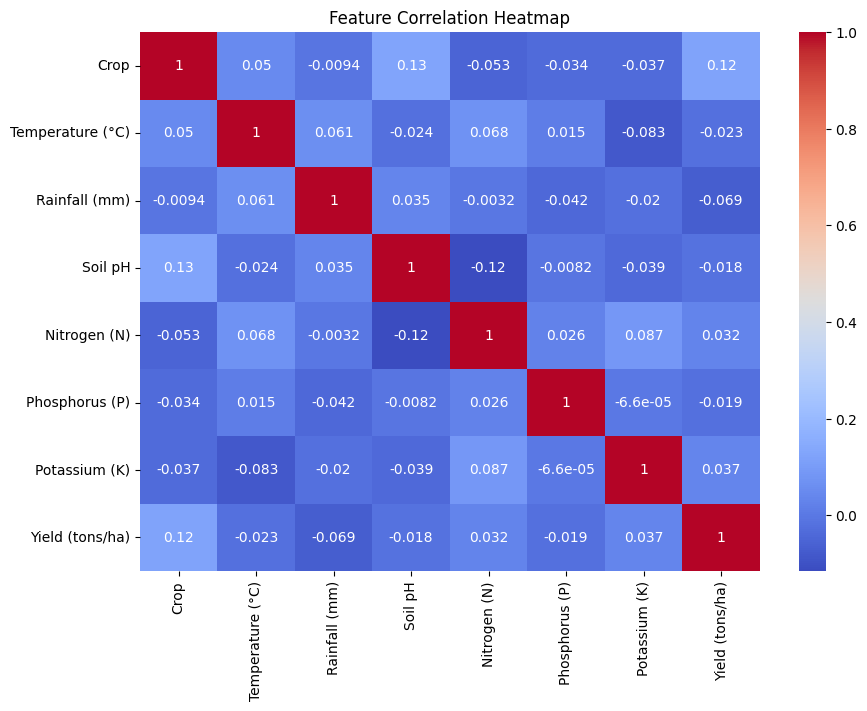

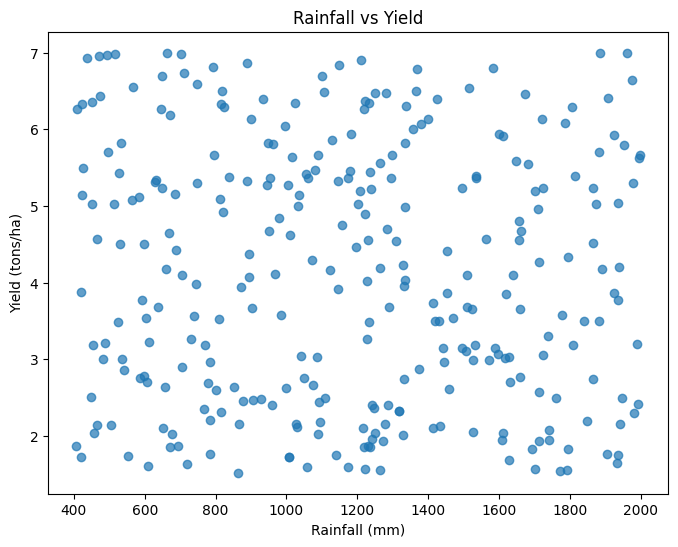

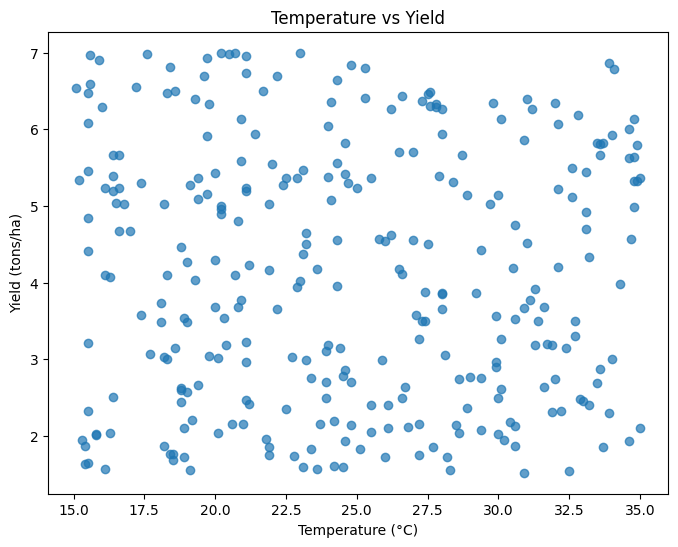

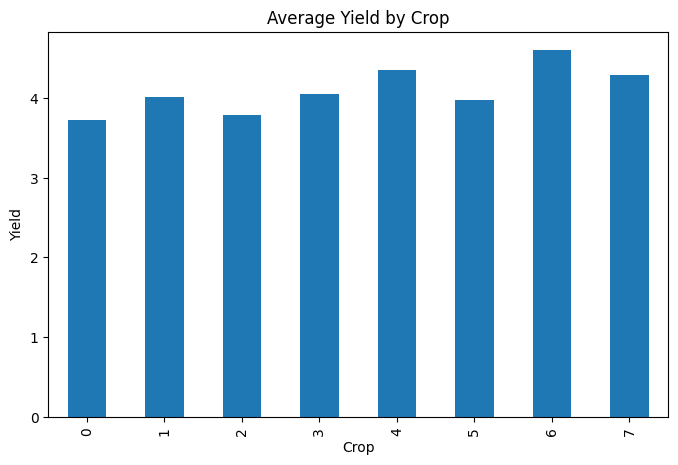


Linear Regression
----------------------------------------
MAE  : 1.3908
RMSE : 1.5694
R²   : 0.0421

Random Forest
----------------------------------------
MAE  : 1.4177
RMSE : 1.6285
R²   : -0.0313


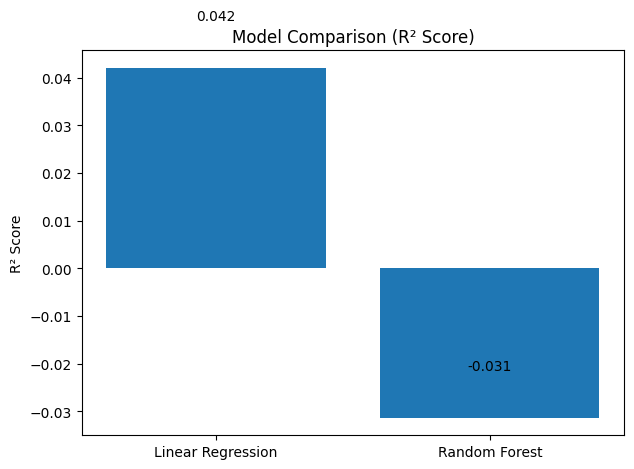

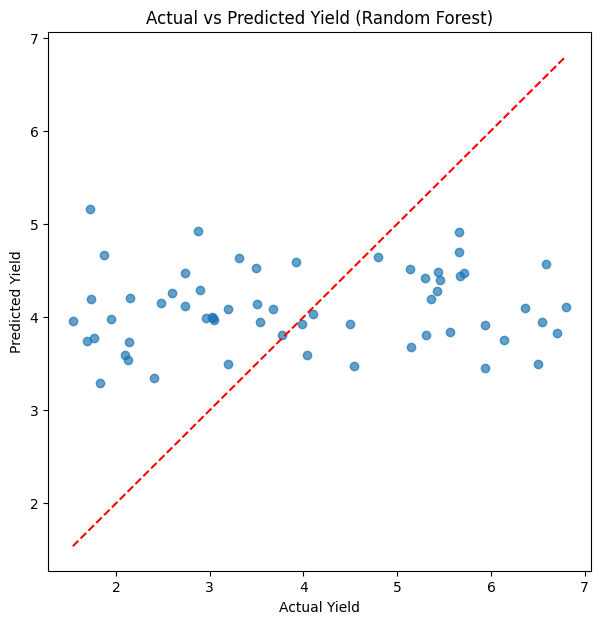

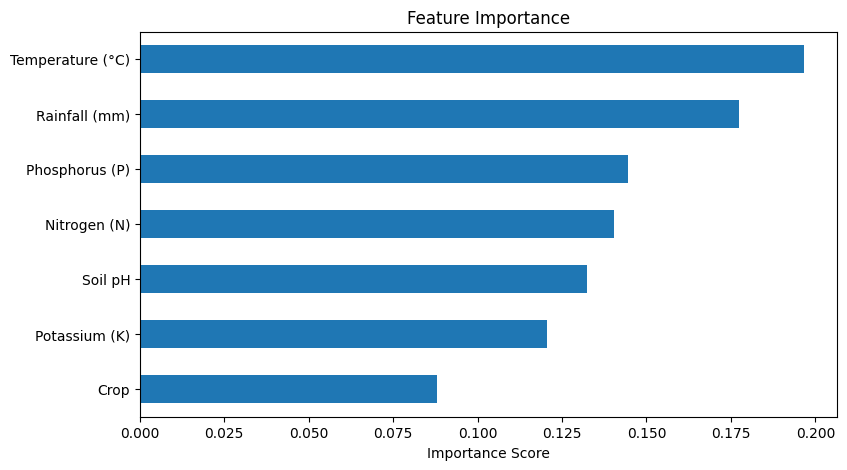


✅ Most Important Features
Temperature (°C)    0.196676
Rainfall (mm)       0.177386
Phosphorus (P)      0.144524
Nitrogen (N)        0.140452
Soil pH             0.132513
Potassium (K)       0.120480
Crop                0.087970
dtype: float64

🌱 Predicted Crop Yield
3.91 tons/ha

📊 Final Model Summary


,Model,R² Score
0,Linear Regression,0.042073
1,Random Forest,-0.031348



✅ PROJECT COMPLETED SUCCESSFULLY


In [ ]:
# ============================================================
# 🌾 CROP YIELD PREDICTION USING MACHINE LEARNING
# ============================================================

# =========================
# IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# =========================
# UPLOAD DATASET
# =========================
uploaded = files.upload()

import io

filename = list(uploaded.keys())[0]

df = pd.read_csv(io.BytesIO(uploaded[filename]))

print("✅ Dataset Loaded Successfully")

display(df.head())

# ============================================================
# DATA PREPROCESSING
# ============================================================

# Drop ID column
df = df.drop(columns=['ID'])

# Encode Crop column
encoder = LabelEncoder()

df['Crop'] = encoder.fit_transform(df['Crop'])

# Features and Target
X = df.drop(columns=['Yield (tons/ha)'])

y = df['Yield (tons/ha)']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("✅ Data Preprocessing Completed")

# ============================================================
# DATA VISUALIZATION
# ============================================================

# ------------------------------------------------
# 1. Correlation Heatmap
# ------------------------------------------------
plt.figure(figsize=(10,7))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()

# ------------------------------------------------
# 2. Rainfall vs Yield
# ------------------------------------------------
plt.figure(figsize=(8,6))

plt.scatter(
    df['Rainfall (mm)'],
    df['Yield (tons/ha)'],
    alpha=0.7
)

plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tons/ha)")
plt.title("Rainfall vs Yield")

plt.show()

# ------------------------------------------------
# 3. Temperature vs Yield
# ------------------------------------------------
plt.figure(figsize=(8,6))

plt.scatter(
    df['Temperature (°C)'],
    df['Yield (tons/ha)'],
    alpha=0.7
)

plt.xlabel("Temperature (°C)")
plt.ylabel("Yield (tons/ha)")
plt.title("Temperature vs Yield")

plt.show()

# ------------------------------------------------
# 4. Average Yield by Crop
# ------------------------------------------------
avg_yield = df.groupby('Crop')['Yield (tons/ha)'].mean()

plt.figure(figsize=(8,5))

avg_yield.plot(kind='bar')

plt.title("Average Yield by Crop")
plt.xlabel("Crop")
plt.ylabel("Yield")

plt.show()

# ============================================================
# MODEL TRAINING
# ============================================================

# ------------------------------------------------
# LINEAR REGRESSION
# ------------------------------------------------
lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

# ------------------------------------------------
# RANDOM FOREST
# ------------------------------------------------
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

# ============================================================
# MODEL EVALUATION
# ============================================================

# Function
def evaluate_model(name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    r2 = r2_score(y_true, y_pred)

    print(f"\n{name}")
    print("-"*40)
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")

# Evaluate
evaluate_model(
    "Linear Regression",
    y_test,
    lr_pred
)

evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
)

# ============================================================
# MODEL COMPARISON GRAPH
# ============================================================

models = ['Linear Regression', 'Random Forest']

r2_scores = [
    r2_score(y_test, lr_pred),
    r2_score(y_test, rf_pred)
]

plt.figure(figsize=(7,5))

bars = plt.bar(models, r2_scores)

plt.title("Model Comparison (R² Score)")
plt.ylabel("R² Score")

for bar, score in zip(bars, r2_scores):

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{score:.3f}',
        ha='center'
    )

plt.show()

# ============================================================
# ACTUAL VS PREDICTED GRAPH
# ============================================================

plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    rf_pred,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")

plt.title("Actual vs Predicted Yield (Random Forest)")

plt.show()

# ============================================================
# FEATURE IMPORTANCE
# ============================================================

importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values()

plt.figure(figsize=(9,5))

importance.plot(kind='barh')

plt.title("Feature Importance")
plt.xlabel("Importance Score")

plt.show()

print("\n✅ Most Important Features")
print(importance.sort_values(ascending=False))

# ============================================================
# PREDICT NEW INPUT
# ============================================================

sample_input = pd.DataFrame([[
    2,      # Crop Encoded
    25,     # Temperature
    700,    # Rainfall
    6.5,    # Soil pH
    60,     # Nitrogen
    45,     # Phosphorus
    50      # Potassium
]], columns=X.columns)

prediction = rf_model.predict(sample_input)

print("\n🌱 Predicted Crop Yield")
print(f"{prediction[0]:.2f} tons/ha")

# ============================================================
# FINAL SUMMARY
# ============================================================

summary = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'R² Score': [
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred)
    ]
})

print("\n📊 Final Model Summary")

display(summary)

print("\n✅ PROJECT COMPLETED SUCCESSFULLY")